In [1]:
# importing libraries and functions
import os
import pandas as pd
from datetime import datetime, timedelta
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from scipy.stats import zscore
import warnings
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV

In [2]:
# Processing manoeuvre and orbital data 

In [3]:
# Helper function for Date conversion
def doy_to_datetime(year: int, doy: int, hour: int, minute: int, second: float=0.0):
    return datetime(year, 1, 1) + timedelta(days=doy - 1, hours=hour, minutes=minute, seconds=second)

In [4]:
# Processing manoeuvre file 'ja1man.txt'
def parse_non_fengyun_line(line):
    parts = line.split()
    if len(parts) < 9:
        return None
    try:
        return {
            'satellite': parts[0],
            'start_time': doy_to_datetime(int(parts[1]), int(parts[2]), int(parts[3]), int(parts[4])),
            'end_time': doy_to_datetime(int(parts[5]), int(parts[6]), int(parts[7]), int(parts[8]))
        }
    except Exception as e:
        print(f"Skipping line due to error: {e}")
        return None

def process_manoeuvre_file(path):
    with open(path) as f:
        data = [parse_non_fengyun_line(line.strip()) for line in f if line.strip()]
    return pd.DataFrame([d for d in data if d])


In [5]:
# Processing orbital elements from 'Jason-1.csv' file

def load_orbital_elements(filepath: str):
    try:
        df = pd.read_csv(filepath, index_col=0, parse_dates=True)
        df.sort_index(inplace=True)
        df.index.name = 'timestamp'
        return df
    except Exception as e:
        print(f"Error loading orbital elements file: {filepath}\n{e}")
        return pd.DataFrame()   


In [6]:
# Loading both files
def main():
    base_dir = './satellite_data'
    manoeuvre_file = os.path.join(base_dir, 'manoeuvres', 'ja1man.txt')
    orbital_file = os.path.join(base_dir, 'orbital_elements', 'Jason-1.csv')

    print(f"\nProcessing manoeuvre file: {manoeuvre_file}")
    man_df = process_manoeuvre_file(manoeuvre_file)
    print(man_df.head())

    print(f"\nProcessing orbital elements file: {orbital_file}")
    orb_df = load_orbital_elements(orbital_file)
    print(orb_df.head())

    return man_df, orb_df

In [7]:
man_df, orb_df = main()


Processing manoeuvre file: ./satellite_data/manoeuvres/ja1man.txt
  satellite          start_time            end_time
0     JASO1 2001-12-11 13:08:00 2001-12-11 15:57:00
1     JASO1 2001-12-13 21:17:00 2001-12-14 00:06:00
2     JASO1 2001-12-17 07:35:00 2001-12-17 10:31:00
3     JASO1 2001-12-20 06:45:00 2001-12-20 09:39:00
4     JASO1 2002-01-10 01:49:00 2002-01-10 04:40:00

Processing orbital elements file: ./satellite_data/orbital_elements/Jason-1.csv
                            eccentricity  argument of perigee  inclination  \
timestamp                                                                    
2001-12-22 04:13:05.190527      0.000851             4.661221     1.152701   
2001-12-23 23:23:38.458751      0.000839             4.615654     1.152689   
2001-12-24 23:45:59.288255      0.000836             4.609627     1.152690   
2001-12-25 22:15:50.795999      0.000830             4.597215     1.152689   
2001-12-26 11:23:15.892799      0.000822             4.593359     1.1526

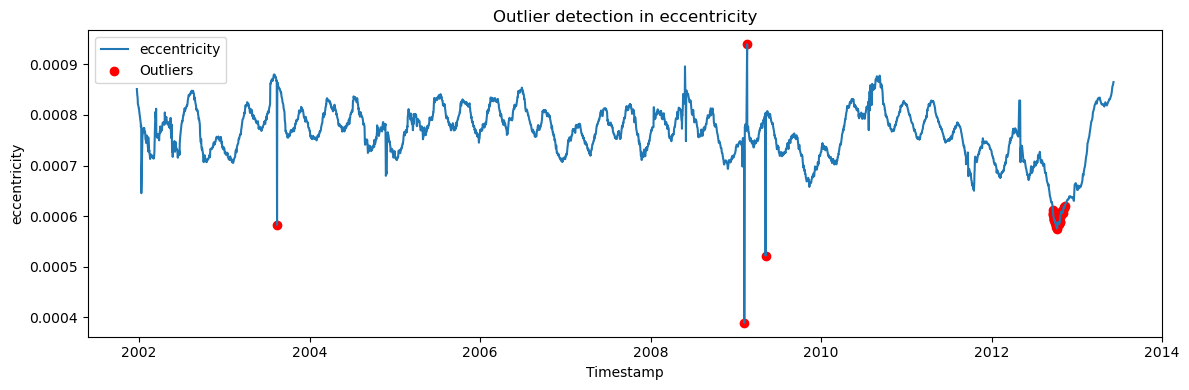

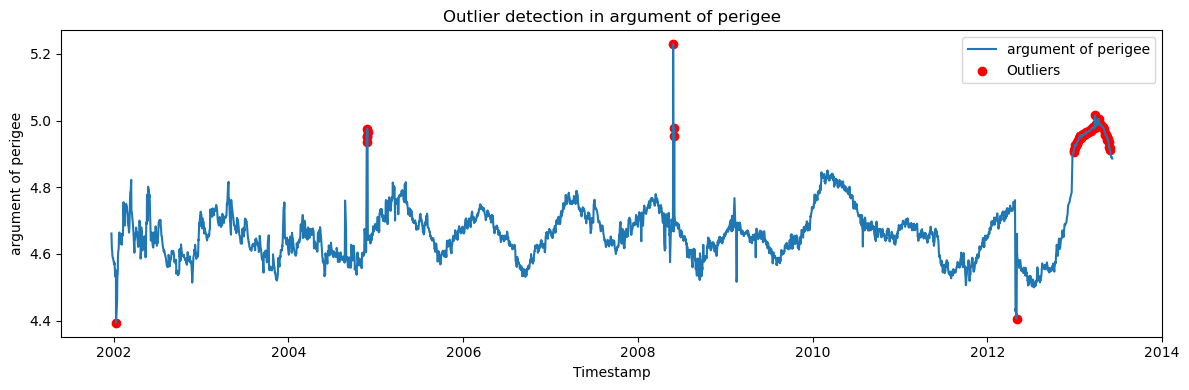

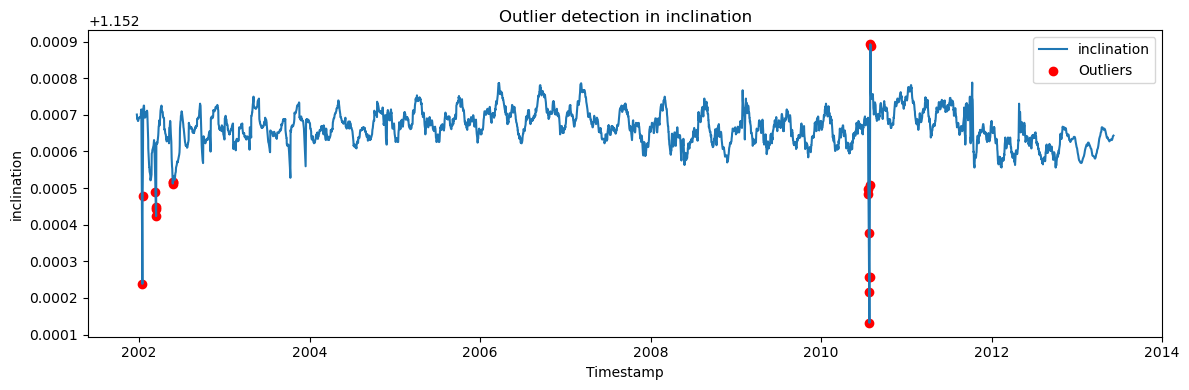

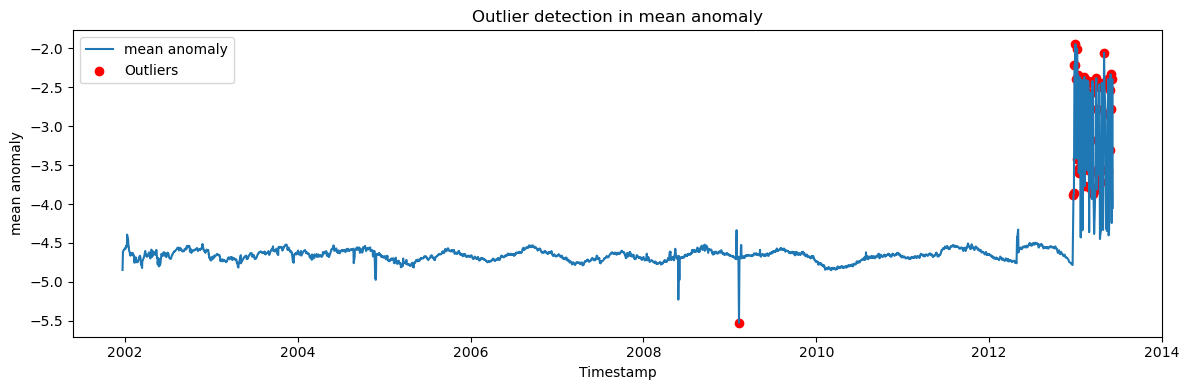

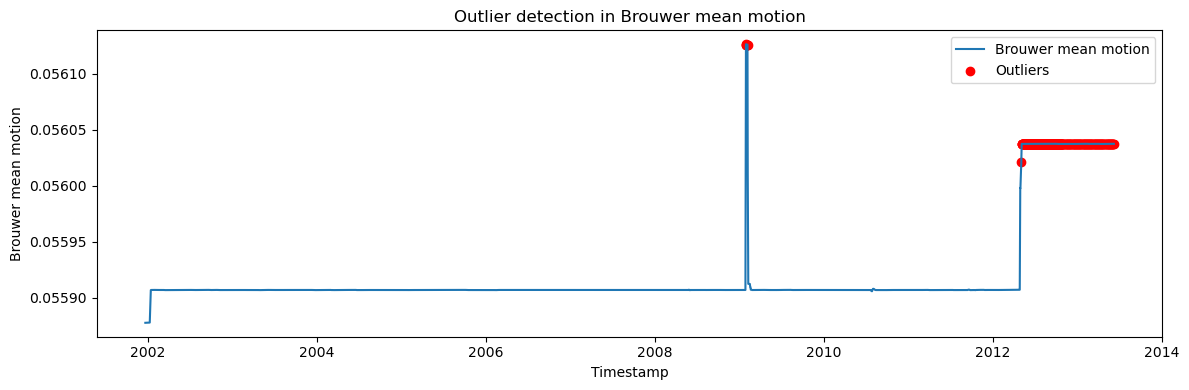

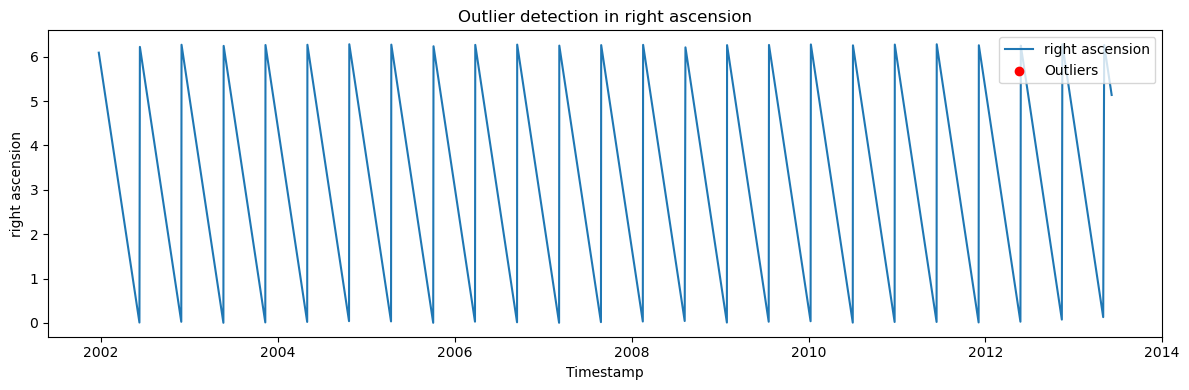

In [8]:
#Detecting outliers
def detect_outliers(df, threshold=3):
    z_scores = df.apply(zscore)
    outliers = (z_scores.abs() > threshold)
    return outliers

def plot_outliers(df, outliers):
    for col in df.columns:
        plt.figure(figsize=(12, 4))
        plt.plot(df.index, df[col], label=col)
        plt.scatter(df.index[outliers[col]], df[col][outliers[col]], color='red', label='Outliers')
        plt.title(f"Outlier detection in {col}")
        plt.legend()
        plt.xlabel("Timestamp")
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()
outliers = detect_outliers(orb_df)
plot_outliers(orb_df, outliers)


 Descriptive Statistics:
       eccentricity  argument of perigee  inclination  mean anomaly  \
count   3996.000000          3996.000000  3996.000000   3996.000000   
mean       0.000767             4.662818     1.152667     -4.630157   
std        0.000049             0.080507     0.000049      0.237119   
min        0.000389             4.393310     1.152132     -5.526137   
25%        0.000737             4.608762     1.152636     -4.698757   
50%        0.000772             4.657633     1.152668     -4.654270   
75%        0.000801             4.703853     1.152699     -4.603103   
max        0.000940             5.228959     1.152893     -1.946838   

       Brouwer mean motion  right ascension  
count          3996.000000      3996.000000  
mean              0.055916         3.156542  
std               0.000035         1.809105  
min               0.055877         0.002243  
25%               0.055907         1.593722  
50%               0.055907         3.169249  
75%         

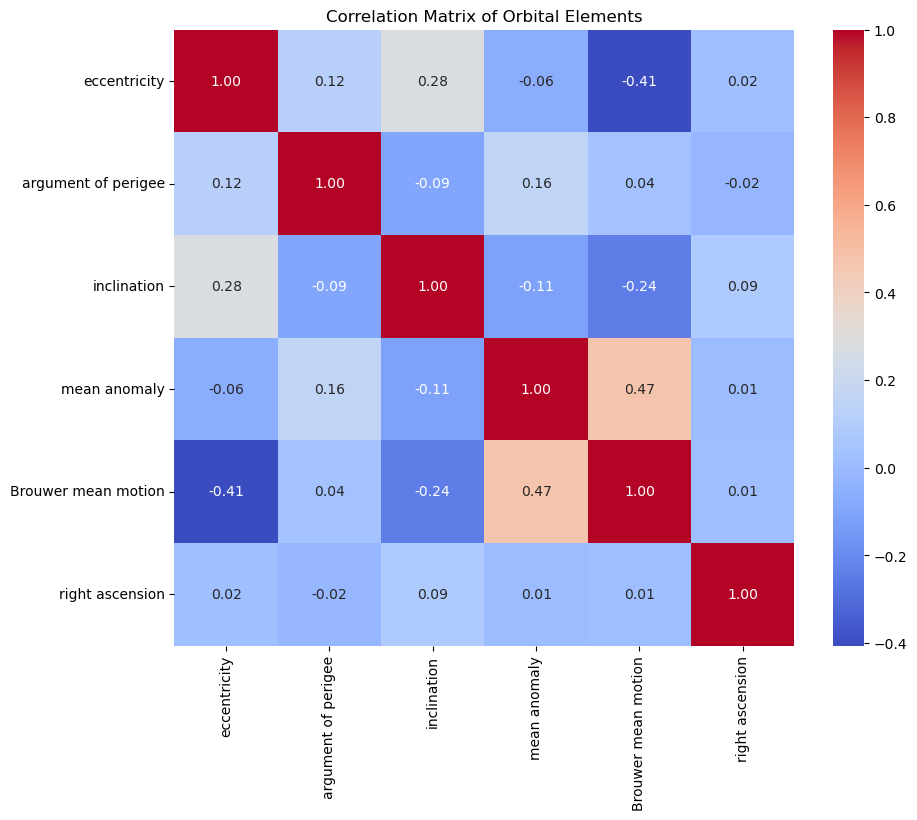

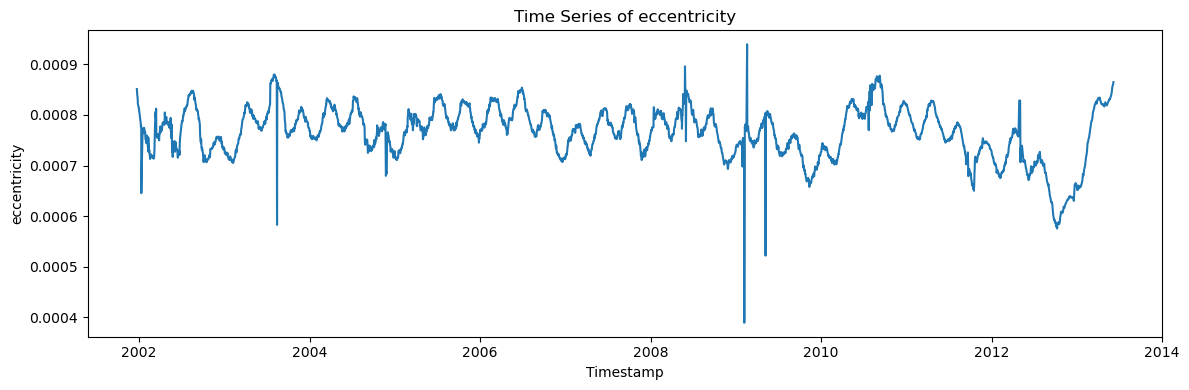

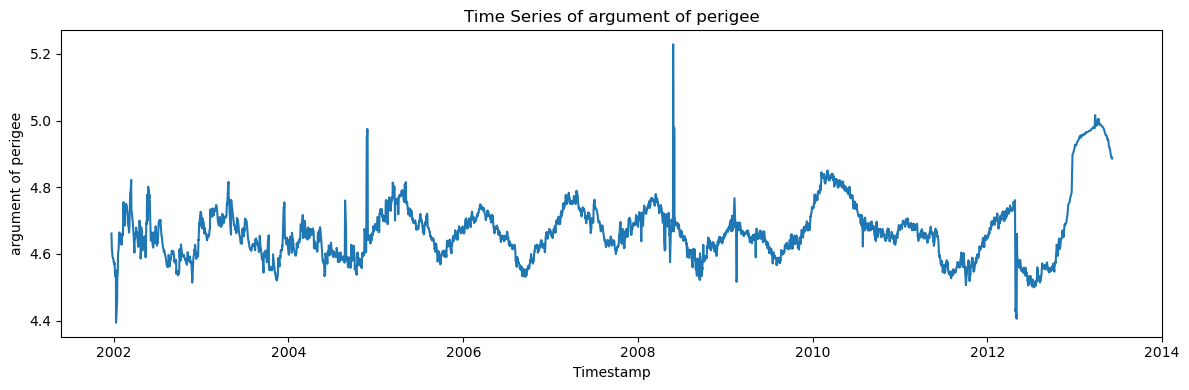

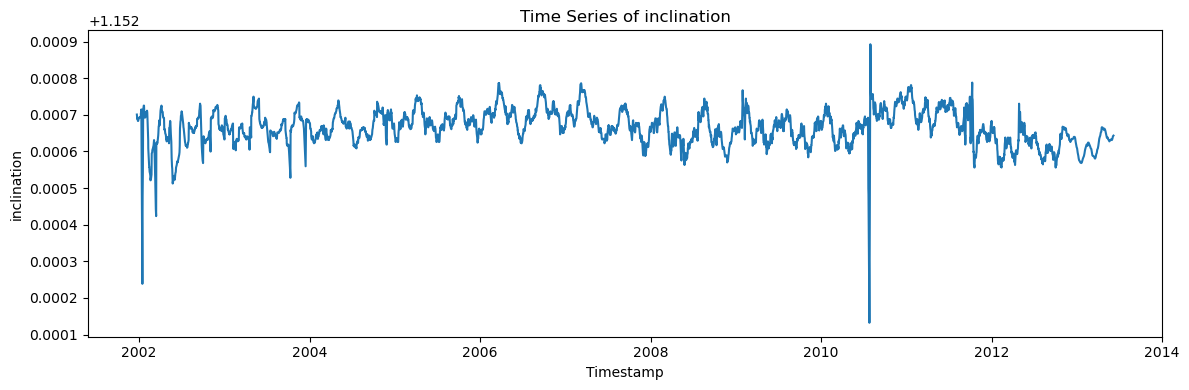

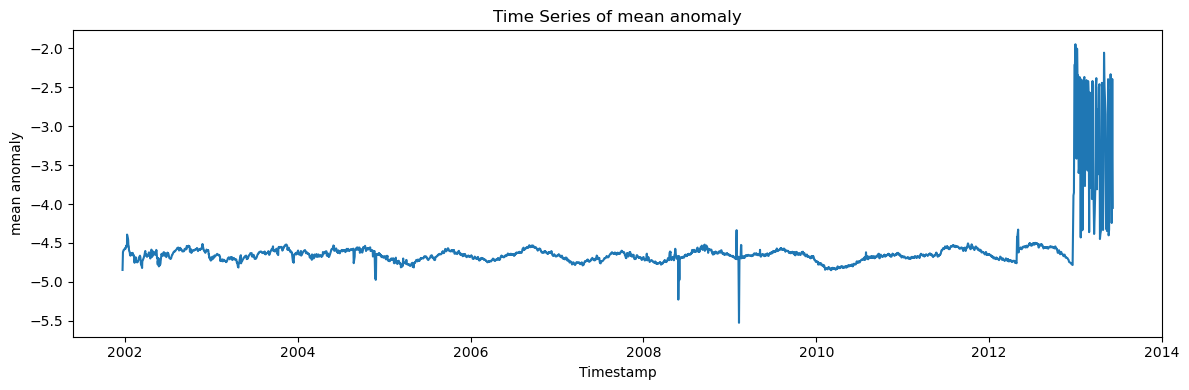

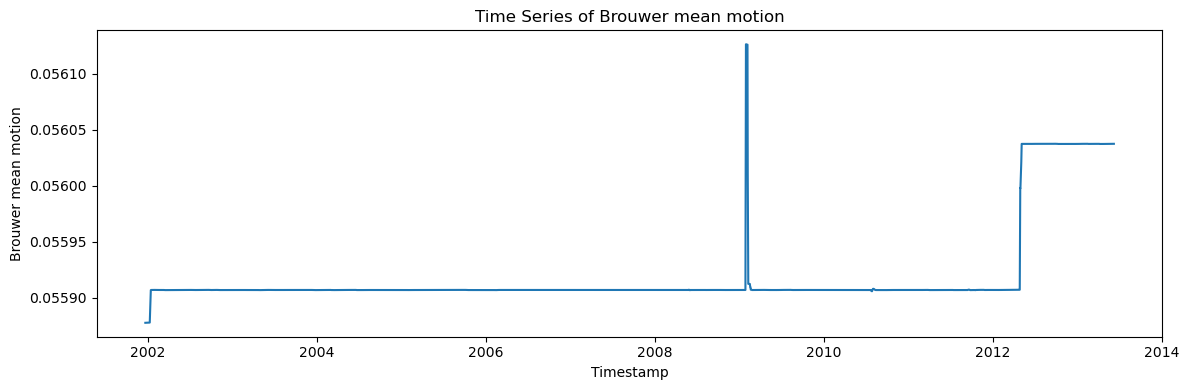

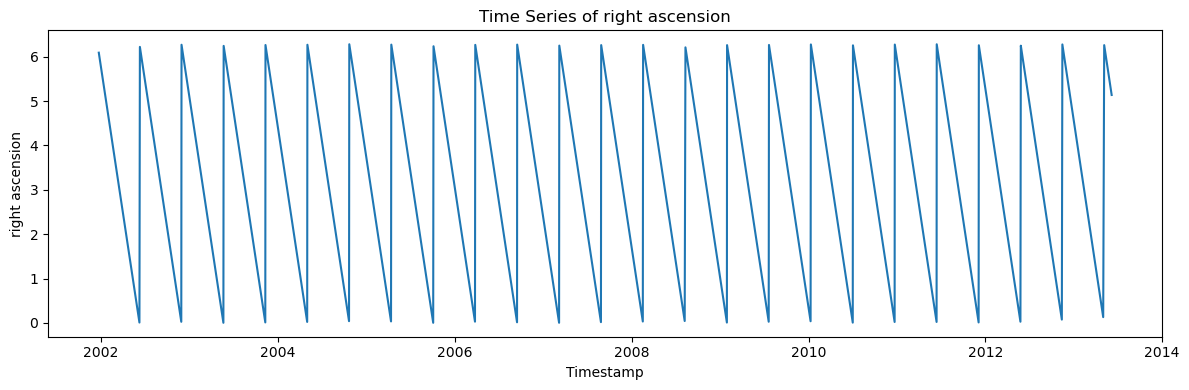

In [9]:
# EDA for all orbital elements

def exploratory_analysis(df):
    print("\n Descriptive Statistics:")
    print(df.describe())

    print("\n Null Values :")
    print(df.isnull().sum())

    print("\nCorrelation Matrix:")
    corr = df.corr()
    print(corr)

    # Heatmap 
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Correlation Matrix of Orbital Elements")
    plt.show()

    # Time series trend plot
    for col in df.columns:
        plt.figure(figsize=(12, 4))
        sns.lineplot(x=df.index, y=df[col])
        plt.title(f"Time Series of {col}")
        plt.xlabel("Timestamp")
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()
exploratory_analysis(orb_df)

<Figure size 1000x400 with 0 Axes>

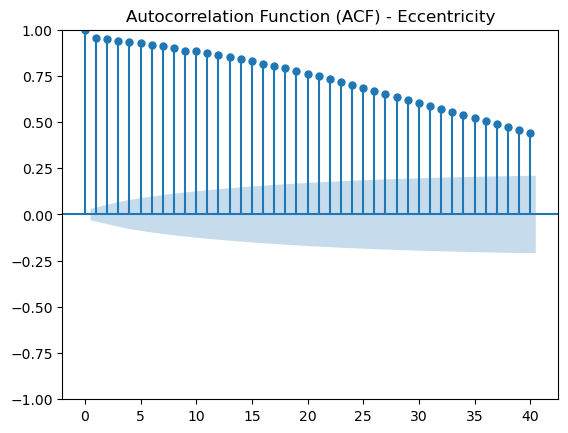

<Figure size 1000x400 with 0 Axes>

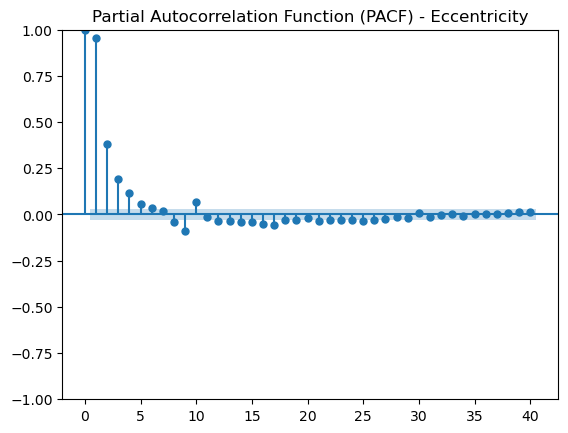


 ADF Test 
ADF Statistic     : -6.811742
p-value           : 0.000000
Critical Values   :
   1%: -3.4320
   5%: -2.8623
   10%: -2.5672

 The series is stationary .


In [10]:
# EDA for 'eccentricity'

series = orb_df['eccentricity'].dropna()

# ACF plot
plt.figure(figsize=(10, 4))
plot_acf(series, lags=40)
plt.title('Autocorrelation Function (ACF) - Eccentricity')
plt.show()

# PACF plot
plt.figure(figsize=(10, 4))
plot_pacf(series, lags=40, method='ywm') 
plt.title('Partial Autocorrelation Function (PACF) - Eccentricity')
plt.show()

# ADF Test
result = adfuller(series)
print('\n ADF Test ')
print(f"ADF Statistic     : {result[0]:.6f}")
print(f"p-value           : {result[1]:.6f}")
print(f"Critical Values   :")
for key, value in result[4].items():
    print(f"   {key}: {value:.4f}")
if result[1] < 0.05:
    print("\n The series is stationary .")
else:
    print("\n The series is NOT stationary.")


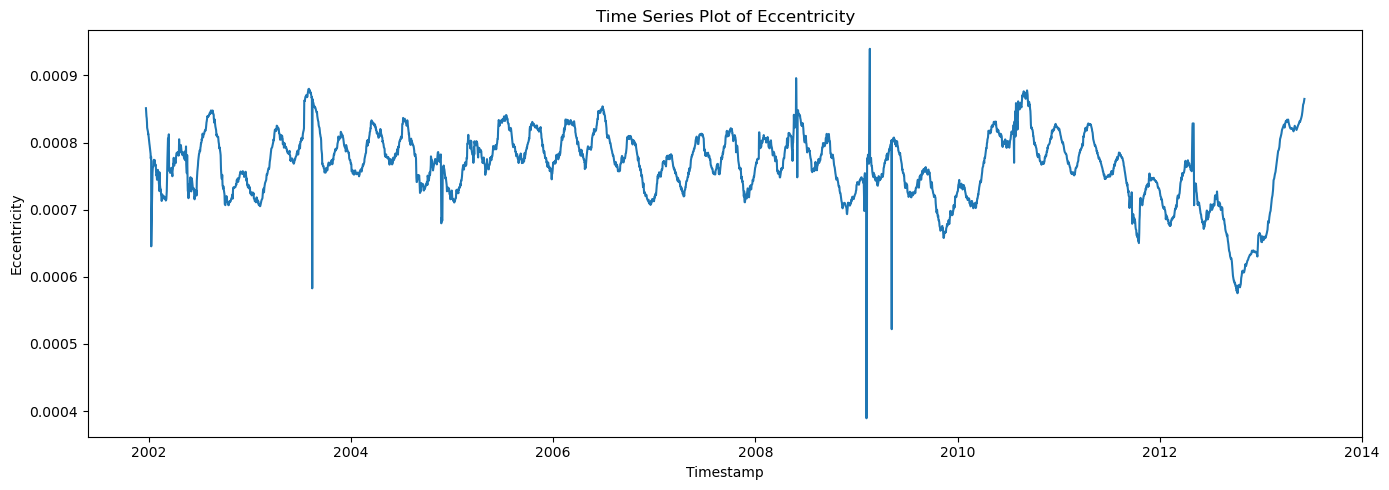

In [11]:
# Plotting the time series to observe seasonality 

def plot_eccentricity_trend(df):  
    plt.figure(figsize=(14, 5))
    sns.lineplot(x=df.index, y=df['eccentricity'])
    plt.title("Time Series Plot of Eccentricity")
    plt.xlabel("Timestamp")
    plt.ylabel("Eccentricity")
    plt.tight_layout()
    plt.show()
plot_eccentricity_trend(orb_df)


In [12]:
# Fill missing values in eccentricity
if orb_df['eccentricity'].isna().sum() > 0:
    orb_df['eccentricity'] = orb_df['eccentricity'].ffill()

In [13]:
# Train Test Split

train_size = int(len(orb_df) * 0.8)
train_data = orb_df['eccentricity'][:train_size]
test_data = orb_df['eccentricity'][train_size:]

print(f"Train data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")



Train data shape: (3196,)
Test data shape: (800,)


In [14]:
# Feature engineering
def create_features(df, target_col='eccentricity', lags=30):
    if isinstance(df, pd.Series):
        df = df.to_frame(name=target_col)
    df = df.copy()
    # temporal features
    df['dayofyear'] = df.index.dayofyear
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year  
    # lag features
    for lag in range(1, lags+1):
        df[f'lag_{lag}'] = df[target_col].shift(lag)   
    # Drop rows with NaN values
    df = df.dropna() 
    return df


In [15]:
# Creating features
target_col = 'eccentricity'
train_features = create_features(train_data, target_col)
test_features = create_features(test_data, target_col)

X_train = train_features.drop(columns=[target_col])
y_train = train_features[target_col]
X_test = test_features.drop(columns=[target_col])
y_test = test_features[target_col]

# Scaling features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [16]:
# model setup 
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
# cross validation
tscv = TimeSeriesSplit(n_splits=3)

In [17]:
# Grid Search
grid_search = GridSearchCV(estimator=xgb_model,
                         param_grid=param_grid,
                         cv=tscv,
                         scoring='neg_mean_squared_error',
                         n_jobs=-1,
                         verbose=1)
grid_search.fit(X_train_scaled, y_train)

# best model
best_xgb = grid_search.best_estimator_
print("\nBest parameters:", grid_search.best_params_)


Fitting 3 folds for each of 32 candidates, totalling 96 fits

Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}


In [18]:
# Training final model ---
best_xgb.fit(X_train_scaled, y_train,
            eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)],
            verbose=False)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [19]:
# slicing the test data to match the shifted length
test_features = create_features(test_data, target_col)
X_test = test_features.drop(columns=[target_col])
y_test = test_features[target_col]

In [21]:
# Make predictions for the full test set ---
test_predictions = best_xgb.predict(X_test_scaled)

In [22]:
# RMSE
train_predictions = best_xgb.predict(X_train_scaled)
train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))

print(f"\nTrain RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")


Train RMSE: 0.0000
Test RMSE: 0.0001


In [23]:
print(len(test_data))
print(len(test_predictions))

800
770


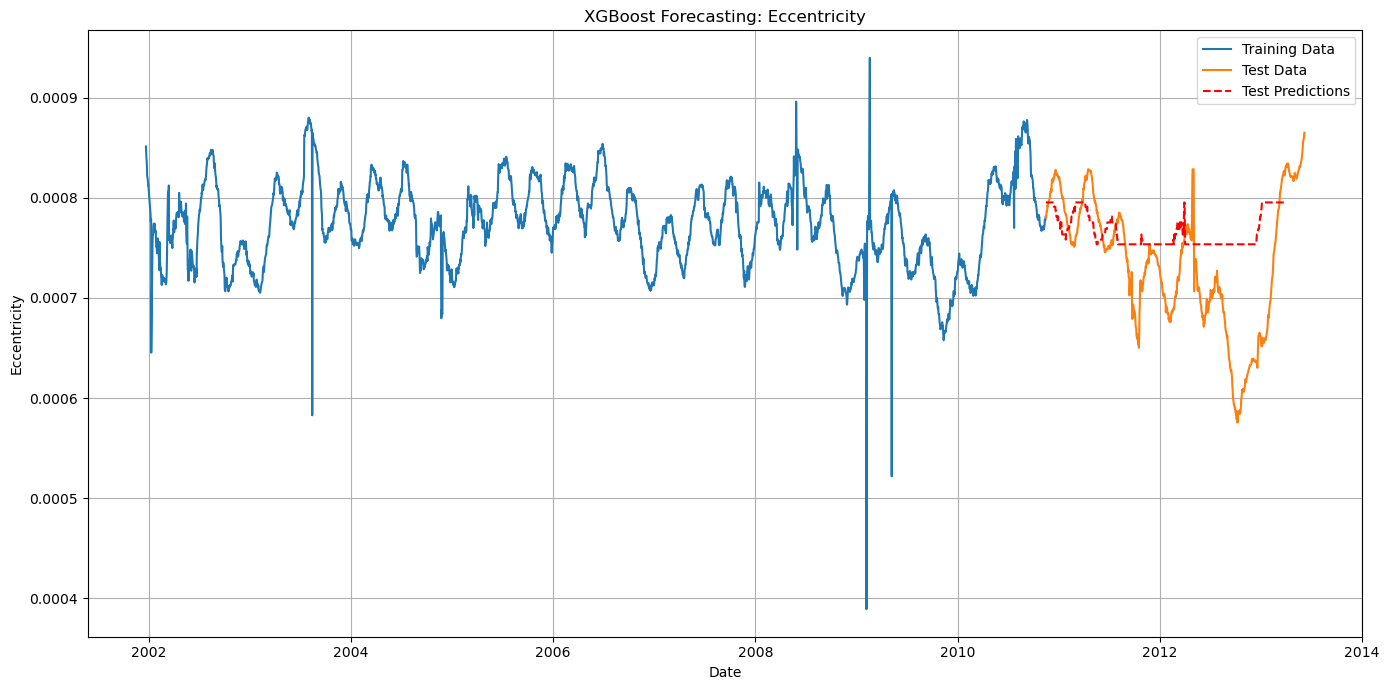

In [24]:
# Plotting prediction vs observed for "eccentricity"
plt.figure(figsize=(14, 7))
plt.plot(train_data.index, train_data.values, label='Training Data')
plt.plot(test_data.index, test_data.values, label='Test Data')
plt.plot(test_data.index[:len(test_predictions)], test_predictions, label='Test Predictions', color='red', linestyle='--') 
plt.title("XGBoost Forecasting: Eccentricity")
plt.xlabel("Date")
plt.ylabel("Eccentricity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


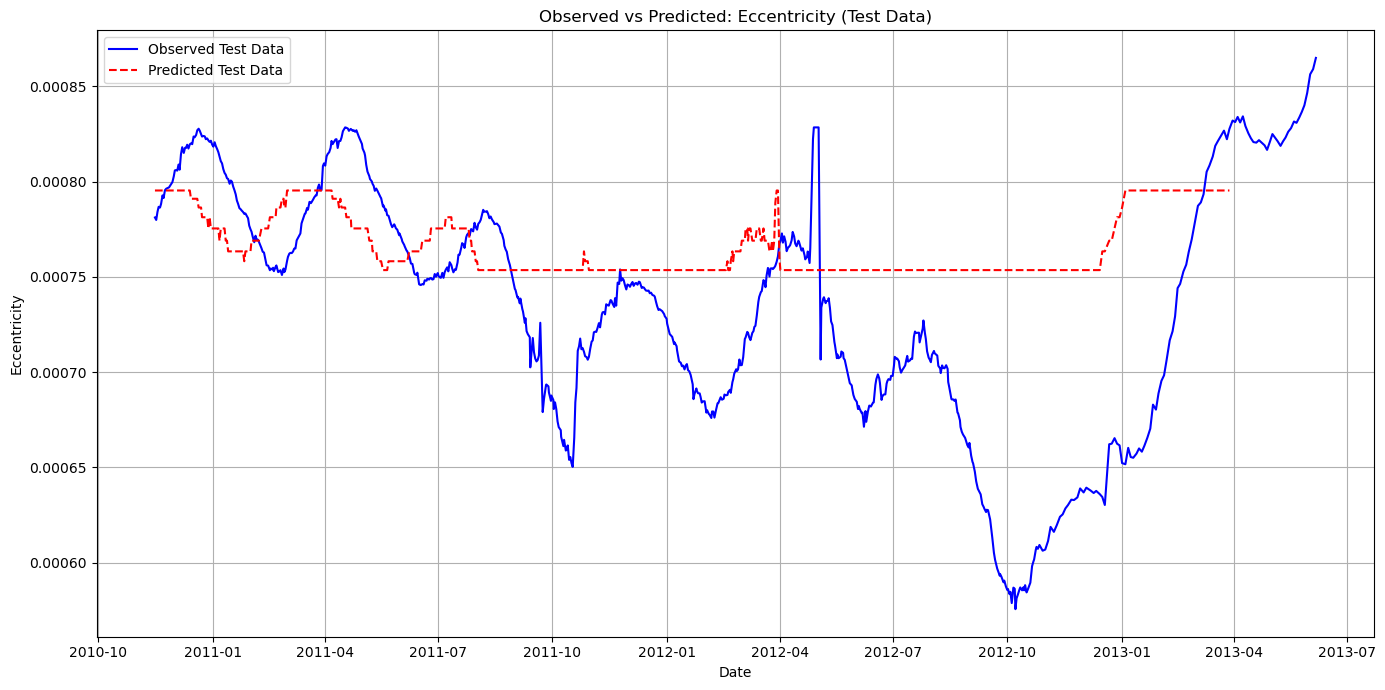

In [25]:
# Plotting only the observed vs predicted for test data
plt.figure(figsize=(14, 7))

# Plotting the observed values
plt.plot(test_data.index, test_data.values, label='Observed Test Data', color='blue')

# Plotting the predicted values
plt.plot(test_data.index[:len(test_predictions)], test_predictions, label='Predicted Test Data', color='red', linestyle='--')

# Adding labels and title
plt.title("Observed vs Predicted: Eccentricity (Test Data)")
plt.xlabel("Date")
plt.ylabel("Eccentricity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


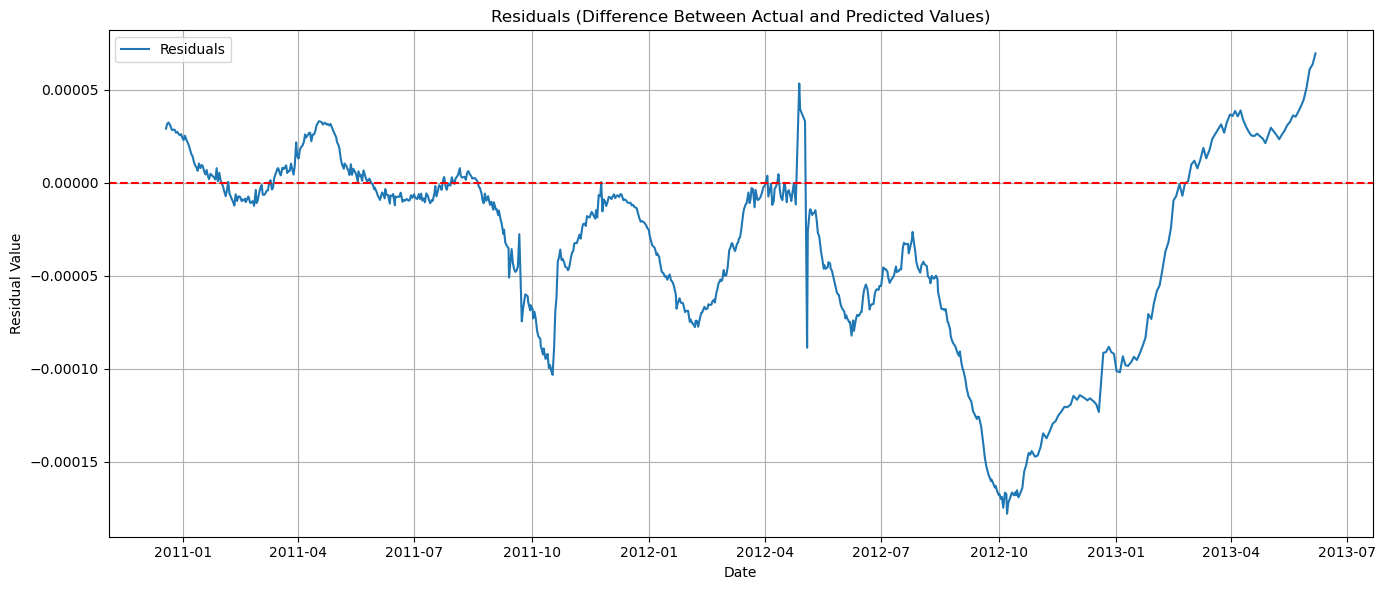

In [26]:
# Residual 
residuals = y_test - test_predictions

# Plotting Residuals
plt.figure(figsize=(14, 6))
plt.plot(y_test.index, residuals, label='Residuals')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals (Difference Between Actual and Predicted Values)')
plt.xlabel('Date')
plt.ylabel('Residual Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [27]:
# Absolute Residuals 
abs_residuals = np.abs(residuals)

# Threshold for Manoeuvre Detection 
threshold_std = abs_residuals.mean() + 2 * abs_residuals.std()
threshold = threshold_std 
print(f"Threshold value used: {threshold:.8f}")

# Detecting Manoeuvres
detected_manoeuvres = residuals[abs_residuals > threshold]

print(f"Number of detected manoeuvre points: {len(detected_manoeuvres)}")

# Group detected points into events
detected_dates = detected_manoeuvres.index.tolist()
manoeuvre_events = []

if detected_dates:
    current_event = [detected_dates[0]]
    for i in range(1, len(detected_dates)):
        if (detected_dates[i] - current_event[-1]).days <= 2:
            current_event.append(detected_dates[i])
        else:
            manoeuvre_events.append({
                'start_time': current_event[0],
                'end_time': current_event[-1],
                'max_residual': abs_residuals[current_event].max()
            })
            current_event = [detected_dates[i]]
    # Add the last event
    manoeuvre_events.append({
        'start_time': current_event[0],
        'end_time': current_event[-1],
        'max_residual': abs_residuals[current_event].max()
    })
detected_df = pd.DataFrame(manoeuvre_events)

print("\nDetected Manoeuvre Events:")
print(detected_df)

Threshold value used: 0.00012710
Number of detected manoeuvre points: 49

Detected Manoeuvre Events:
                  start_time                   end_time  max_residual
0 2012-09-16 19:25:01.889760 2012-11-14 11:06:58.999968      0.000178


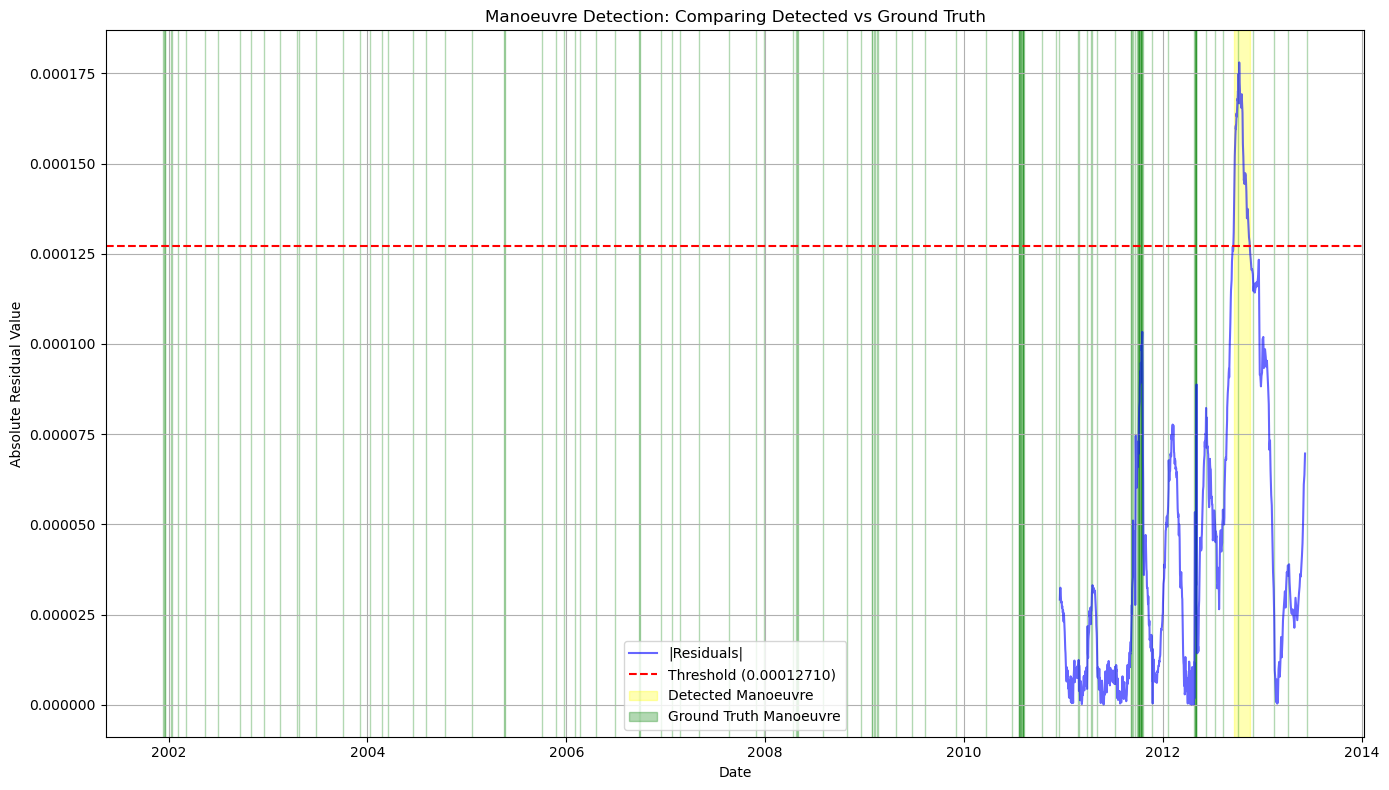

In [28]:
# Plotting Detected Manoeuvres vs Ground Truth
plt.figure(figsize=(14, 8))

#absolute residuals
plt.plot(abs_residuals.index, abs_residuals, label='|Residuals|', color='blue', alpha=0.6)
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold ({threshold:.8f})')
# detected manoeuvre
for idx, event in enumerate(manoeuvre_events):
    plt.axvspan(event['start_time'], event['end_time'], 
                alpha=0.3, color='yellow', label='Detected Manoeuvre' if idx == 0 else '')
# ground truth manoeuvres 
for idx, row in man_df.iterrows():
    plt.axvspan(row['start_time'], row['end_time'], 
                alpha=0.3, color='green', label='Ground Truth Manoeuvre' if idx == 0 else '')

plt.title('Manoeuvre Detection: Comparing Detected vs Ground Truth')
plt.xlabel('Date')
plt.ylabel('Absolute Residual Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [29]:

# Calculate Accuracy Metrics 
def calculate_detection_accuracy(detected_df, ground_truth_df, tolerance_days=3):
    true_positives = 0
    false_positives = 0
    for _, det_event in detected_df.iterrows():
        matched = False
        for _, gt_event in ground_truth_df.iterrows():
            if (
                (det_event['start_time'] <= gt_event['end_time'] and 
                 det_event['end_time'] >= gt_event['start_time']) or
                (abs((det_event['start_time'] - gt_event['start_time']).days) <= tolerance_days or
                 abs((det_event['end_time'] - gt_event['end_time']).days) <= tolerance_days)
            ):
                matched = True
                break
        if matched:
            true_positives += 1
        else:
            false_positives += 1
    false_negatives = 0
    for _, gt_event in ground_truth_df.iterrows():
        matched = False
        for _, det_event in detected_df.iterrows():
            if (
                (det_event['start_time'] <= gt_event['end_time'] and 
                 det_event['end_time'] >= gt_event['start_time']) or
                (abs((det_event['start_time'] - gt_event['start_time']).days) <= tolerance_days or
                 abs((det_event['end_time'] - gt_event['end_time']).days) <= tolerance_days)
            ):
                matched = True
                break

        if not matched:
            false_negatives += 1
    # Metrics
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return {
        'true_positives': true_positives,
        'false_positives': false_positives,
        'false_negatives': false_negatives,
        'precision': precision,
        'recall': recall,
        'f1_score': f1_score
    }


In [30]:
metrics = calculate_detection_accuracy(detected_df, man_df)
print("\nDetection Accuracy Metrics:")
print(f"True Positives: {metrics['true_positives']}")
print(f"False Positives: {metrics['false_positives']}")
print(f"False Negatives: {metrics['false_negatives']}")
print(f"Precision: {metrics['precision']:.4f}")
print(f"Recall: {metrics['recall']:.4f}")
print(f"F1 Score: {metrics['f1_score']:.4f}")



Detection Accuracy Metrics:
True Positives: 1
False Positives: 0
False Negatives: 118
Precision: 1.0000
Recall: 0.0084
F1 Score: 0.0167


In [31]:
# Print summary tables
print("\nDetected Manoeuvres:")
print(detected_df[['start_time', 'end_time', 'max_residual']])

print("\nGround Truth Manoeuvres:")
print(man_df[['start_time', 'end_time']])



Detected Manoeuvres:
                  start_time                   end_time  max_residual
0 2012-09-16 19:25:01.889760 2012-11-14 11:06:58.999968      0.000178

Ground Truth Manoeuvres:
             start_time            end_time
0   2001-12-11 13:08:00 2001-12-11 15:57:00
1   2001-12-13 21:17:00 2001-12-14 00:06:00
2   2001-12-17 07:35:00 2001-12-17 10:31:00
3   2001-12-20 06:45:00 2001-12-20 09:39:00
4   2002-01-10 01:49:00 2002-01-10 04:40:00
..                  ...                 ...
114 2012-10-02 23:57:00 2012-10-02 23:58:00
115 2012-11-26 00:14:00 2012-11-26 00:15:00
116 2013-02-13 21:53:00 2013-02-13 21:53:00
117 2013-04-03 22:34:00 2013-04-03 22:35:00
118 2013-06-13 22:32:00 2013-06-13 22:33:00

[119 rows x 2 columns]


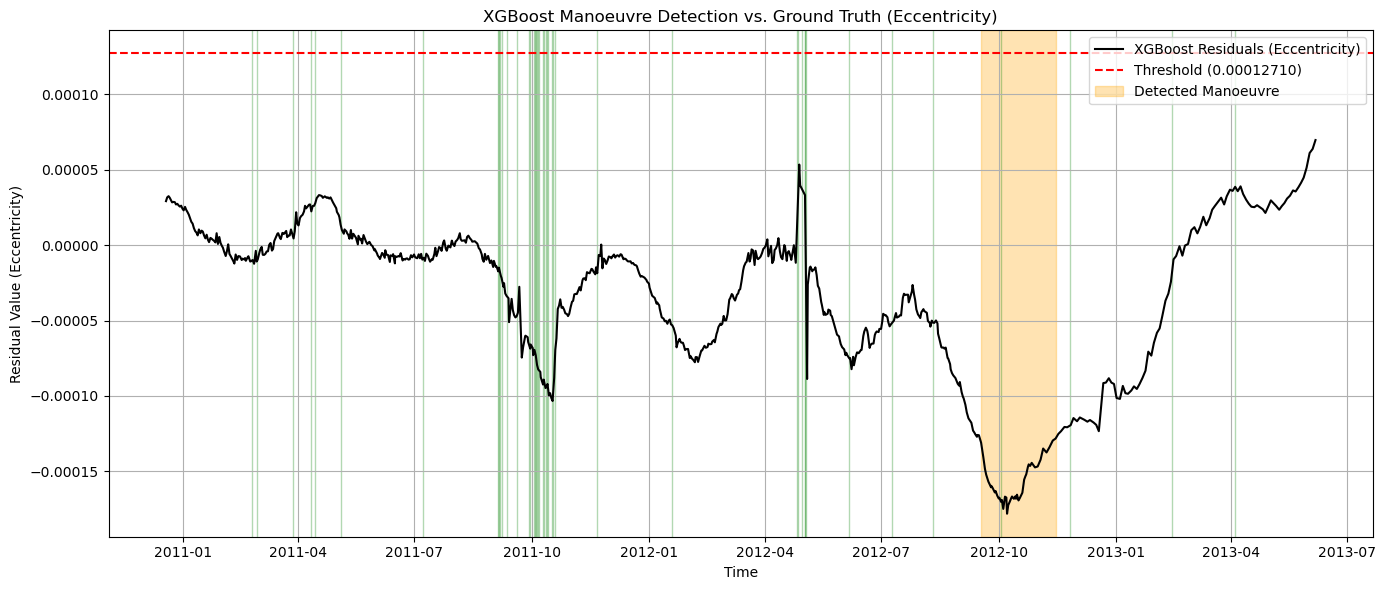

In [32]:
# Filtering ground truth manoeuvres
man_df_filtered = man_df[
    (man_df['start_time'] >= residuals.index.min()) &
    (man_df['end_time'] <= residuals.index.max())
]

plt.figure(figsize=(14, 6))

#  residuals 
plt.plot(residuals.index, residuals.values, label='XGBoost Residuals (Eccentricity)', color='black')
# threshold 
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold ({threshold:.8f})')
# detected manoeuvres
if not detected_df.empty:
    for idx, row in detected_df.iterrows():
        plt.axvspan(row['start_time'], row['end_time'], color='orange', alpha=0.3,
                    label='Detected Manoeuvre' if idx == 0 else "")
# ground truth manoeuvres 
if not man_df_filtered.empty:
    for idx, row in man_df_filtered.iterrows():
        plt.axvspan(row['start_time'], row['end_time'], color='green', alpha=0.3,
                    label='Ground Truth Manoeuvre' if idx == 0 else "")

plt.xlabel('Time')
plt.ylabel('Residual Value (Eccentricity)')
plt.title('XGBoost Manoeuvre Detection vs. Ground Truth (Eccentricity)')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()


In [33]:
def detect_anomalies(residuals, threshold):
    anomaly_mask = residuals.abs() > threshold
    return residuals[anomaly_mask]


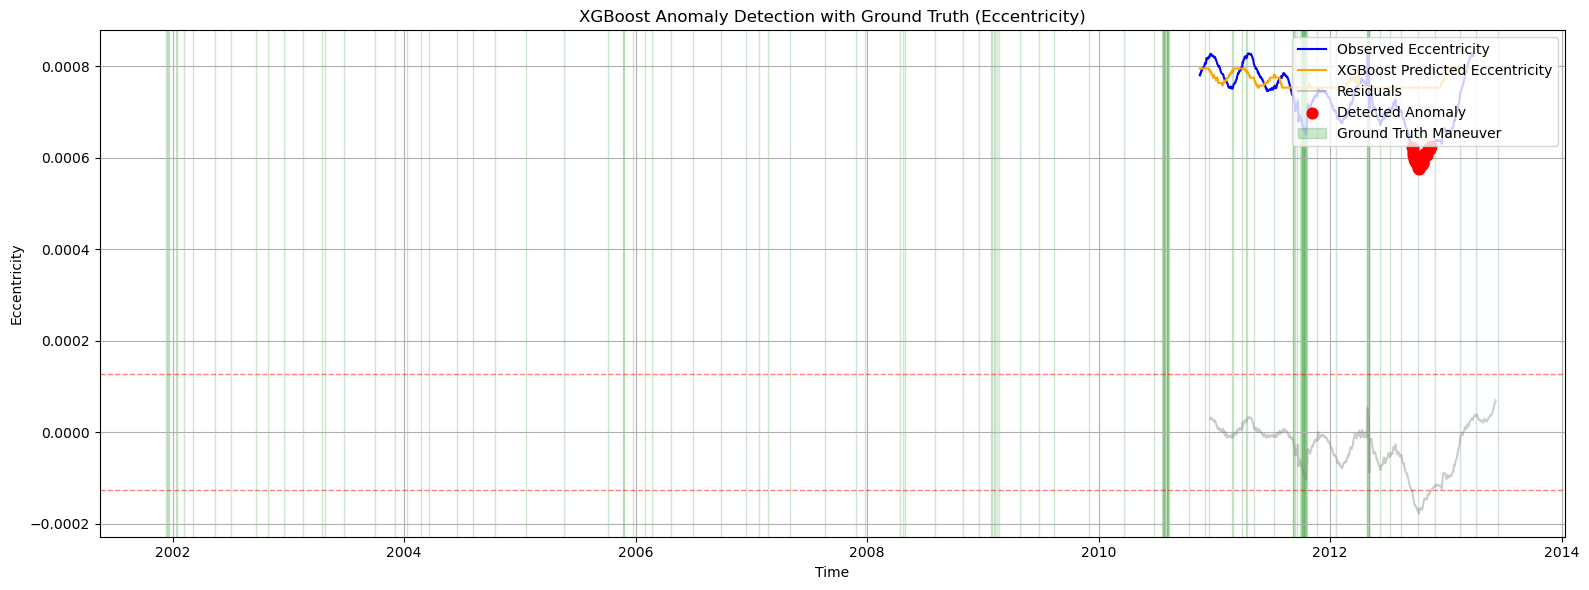

In [34]:
def plot_all_in_one_xgboost(observed, predicted, residuals, threshold, man_df):
    if len(predicted) != len(observed):
        min_len = min(len(observed), len(predicted))
        observed = observed.iloc[:min_len]
        predicted = predicted[:min_len]
        residuals = residuals.iloc[:min_len]
    if not isinstance(predicted, pd.Series):
        predicted = pd.Series(predicted, index=observed.index)

    #  anomalies
    anomalies = detect_anomalies(residuals, threshold)
    anomalies = anomalies[anomalies.index.isin(observed.index)]
    anomalies_observed = observed[observed.index.isin(anomalies.index)]

    # plot
    fig, ax = plt.subplots(figsize=(16, 6))
    # Observed and Predicted 
    ax.plot(observed.index, observed.values, label='Observed Eccentricity', color='blue', linewidth=1.5)
    ax.plot(predicted.index, predicted.values, label='XGBoost Predicted Eccentricity', color='orange', linewidth=1.5)
    #  residuals
    ax.plot(residuals.index, residuals.values, color='grey', alpha=0.4, label='Residuals')
    # anomalies
    if not anomalies_observed.empty:
        ax.scatter(anomalies_observed.index, anomalies_observed.values, color='red', s=60, label='Detected Anomaly', zorder=5)
    # threshold lines 
    ax.axhline(y=threshold, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax.axhline(y=-threshold, color='red', linestyle='--', linewidth=1, alpha=0.5)
    # Ground Truth Maneuvers
    for idx, row in man_df.iterrows():
        ax.axvspan(row['start_time'], row['end_time'], color='green', alpha=0.2,
                   label='Ground Truth Maneuver' if idx == man_df.index[0] else "")
    ax.set_title("XGBoost Anomaly Detection with Ground Truth (Eccentricity)")
    ax.set_xlabel("Time")
    ax.set_ylabel("Eccentricity")
    ax.legend(loc='upper right')
    ax.grid(True)
    plt.tight_layout()
    plt.show()
plot_all_in_one_xgboost(test_data, test_predictions, residuals, threshold, man_df)


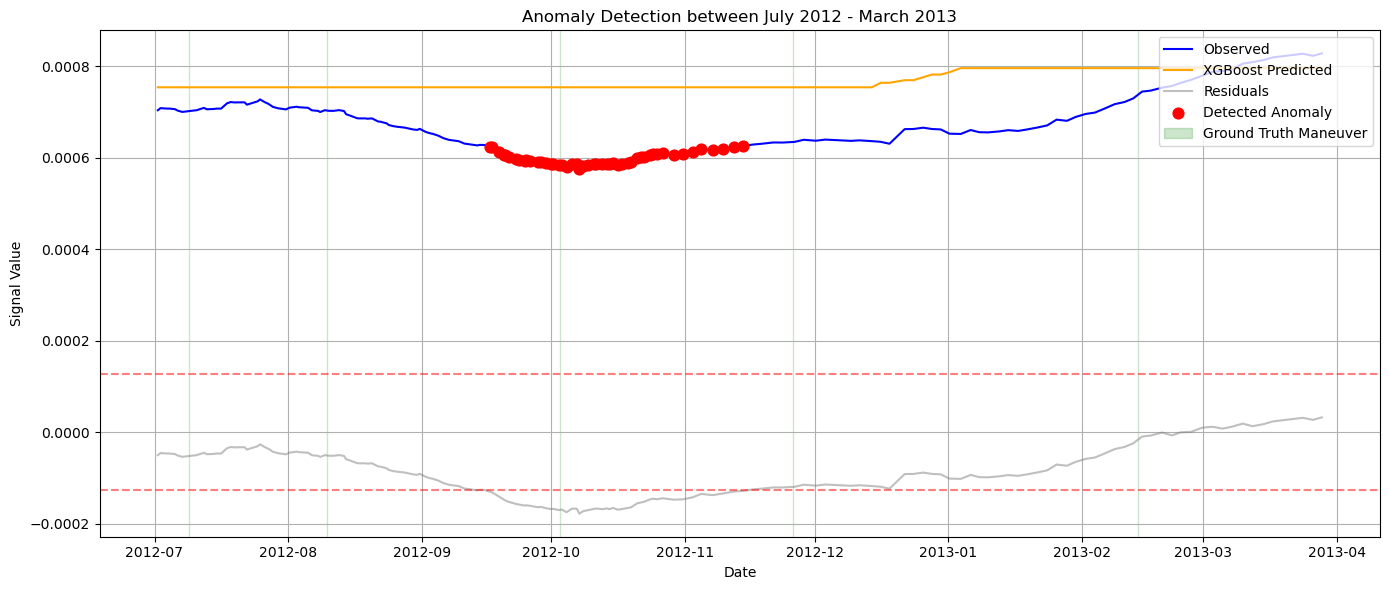

In [35]:
# focused plot
plot_start = '2012-07-01'
plot_end = '2013-03-31'

observed_window = test_data[(test_data.index >= plot_start) & (test_data.index <= plot_end)]

predicted_series = pd.Series(test_predictions, index=test_data.index[:len(test_predictions)])
predicted_window = predicted_series[(predicted_series.index >= plot_start) & (predicted_series.index <= plot_end)]

# Residuals and anomalies
residuals_window = residuals[(residuals.index >= plot_start) & (residuals.index <= plot_end)]
anomalies_window = detect_anomalies(residuals_window, threshold)

# Ground truth maneuvers
valid_man_window = man_df[
    (man_df['start_time'] <= plot_end) &
    (man_df['end_time'] >= plot_start)
]

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 6))

# Observed and predicted
ax.plot(observed_window.index, observed_window.values, label='Observed', color='blue', linewidth=1.5)
ax.plot(predicted_window.index, predicted_window.values, label='XGBoost Predicted', color='orange', linewidth=1.5)
ax.plot(residuals_window.index, residuals_window.values, label='Residuals', color='grey', alpha=0.5)

# Anomalies
ax.scatter(anomalies_window.index, observed_window.loc[anomalies_window.index], color='red', s=60, label='Detected Anomaly', zorder=5)

# Threshold 
ax.axhline(threshold, linestyle='--', color='red', alpha=0.5)
ax.axhline(-threshold, linestyle='--', color='red', alpha=0.5)

# Ground truth maneuver 
for idx, row in valid_man_window.iterrows():
    ax.axvspan(row['start_time'], row['end_time'], color='green', alpha=0.2,
               label='Ground Truth Maneuver' if idx == valid_man_window.index[0] else "")

ax.set_title("Anomaly Detection between July 2012 - March 2013")
ax.set_xlabel("Date")
ax.set_ylabel("Signal Value")
ax.legend(loc='upper right')
ax.grid(True)
plt.tight_layout()
plt.show()
